Import Library

In [21]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.metrics import f1_score

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
import joblib

sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (10, 6)

Load Dataset

In [22]:
df = pd.read_csv('Dataset/healthy_diet_calorie_intake.csv')
df.head()

,Person_ID,Age,Gender,Height_cm,Weight_kg,BMI,Activity_Level,Daily_Calorie_Requirement,Daily_Calorie_Consumed,Protein_Intake_g,Carbohydrate_Intake_g,Fat_Intake_g,Water_Intake_Liters,Diet_Type,Health_Status
0,P0001,50,Male,176.4,74.8,24.0,Very Active,2852,2625,183.0,16.9,202.8,3.3,Keto,Healthy
1,P0002,18,Female,167.6,75.5,26.9,Sedentary,1904,2044,90.1,306.5,50.8,1.9,Vegan,Overweight
2,P0003,68,Female,161.9,87.2,33.3,Lightly Active,2009,2540,222.7,281.3,58.2,2.4,High Protein,Obese
3,P0004,22,Female,169.3,66.9,23.3,Moderately Active,2318,2096,69.5,299.8,68.7,2.9,Balanced,Healthy
4,P0005,30,Male,179.1,75.3,23.5,Sedentary,2144,1937,32.9,285.6,73.7,2.2,Balanced,Healthy


In [23]:
df.shape

(6000, 15)

In [24]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6000 entries, 0 to 5999
Data columns (total 15 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   Person_ID                  6000 non-null   object 
 1   Age                        6000 non-null   int64  
 2   Gender                     6000 non-null   object 
 3   Height_cm                  6000 non-null   float64
 4   Weight_kg                  6000 non-null   float64
 5   BMI                        6000 non-null   float64
 6   Activity_Level             6000 non-null   object 
 7   Daily_Calorie_Requirement  6000 non-null   int64  
 8   Daily_Calorie_Consumed     6000 non-null   int64  
 9   Protein_Intake_g           6000 non-null   float64
 10  Carbohydrate_Intake_g      6000 non-null   float64
 11  Fat_Intake_g               6000 non-null   float64
 12  Water_Intake_Liters        6000 non-null   float64
 13  Diet_Type                  6000 non-null   objec

Looking for missing values

In [25]:
missing = df.isnull().sum().sort_values(ascending=False)
missing

Person_ID                    0
Age                          0
Gender                       0
Height_cm                    0
Weight_kg                    0
BMI                          0
Activity_Level               0
Daily_Calorie_Requirement    0
Daily_Calorie_Consumed       0
Protein_Intake_g             0
Carbohydrate_Intake_g        0
Fat_Intake_g                 0
Water_Intake_Liters          0
Diet_Type                    0
Health_Status                0
dtype: int64

Duplicate check

In [26]:
df.duplicated().sum()

np.int64(0)

In [27]:
pd.set_option('display.max_columns', None)
df.describe().T

,count,mean,std,min,25%,50%,75%,max
Age,6000.0,48.817167,18.141837,18.0,33.0,48.00,65.000,80.0
Height_cm,6000.0,168.592533,9.160213,145.0,161.7,168.20,175.200,198.6
Weight_kg,6000.0,74.070933,12.417877,40.0,65.5,74.10,82.700,116.6
BMI,6000.0,26.094300,4.162643,12.9,23.3,26.00,28.900,44.0
Daily_Calorie_Requirement,6000.0,2286.223833,469.541134,1223.0,1941.0,2232.50,2581.250,4079.0
Daily_Calorie_Consumed,6000.0,2490.520333,602.279679,1000.0,2057.0,2433.00,2859.000,5158.0
Protein_Intake_g,6000.0,123.773150,61.999158,17.4,78.8,108.90,155.100,457.5
Carbohydrate_Intake_g,6000.0,288.035317,123.914738,-23.6,229.1,297.15,366.125,729.7
Fat_Intake_g,6000.0,93.698417,43.953993,23.2,65.9,82.30,105.100,341.7
Water_Intake_Liters,6000.0,2.734917,0.681486,1.5,2.2,2.60,3.100,5.0


In [28]:
df.columns.tolist()

['Person_ID',
 'Age',
 'Gender',
 'Height_cm',
 'Weight_kg',
 'BMI',
 'Activity_Level',
 'Daily_Calorie_Requirement',
 'Daily_Calorie_Consumed',
 'Protein_Intake_g',
 'Carbohydrate_Intake_g',
 'Fat_Intake_g',
 'Water_Intake_Liters',
 'Diet_Type',
 'Health_Status']

Divide Numeric and Categorical Features

In [29]:
num_cols = df.select_dtypes(include=np.number).columns.to_list()
cat_cols = df.select_dtypes(exclude=np.number).columns.to_list()
print('Number :',num_cols)
print('Categorical :',cat_cols)

Number : ['Age', 'Height_cm', 'Weight_kg', 'BMI', 'Daily_Calorie_Requirement', 'Daily_Calorie_Consumed', 'Protein_Intake_g', 'Carbohydrate_Intake_g', 'Fat_Intake_g', 'Water_Intake_Liters']
Categorical : ['Person_ID', 'Gender', 'Activity_Level', 'Diet_Type', 'Health_Status']


Exploratory Data Analysis (EDA)

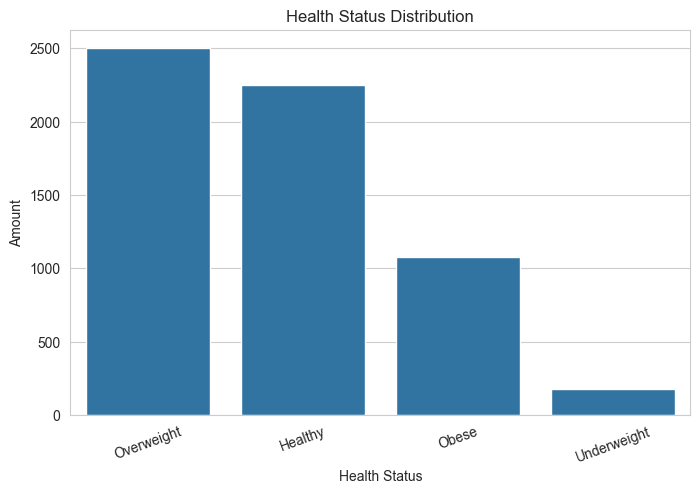

In [30]:
plt.figure(figsize=(8,5))
sns.countplot(data=df, x='Health_Status', order=df['Health_Status'].value_counts().index)
plt.title('Health Status Distribution')
plt.xlabel('Health Status')
plt.ylabel('Amount')
plt.xticks(rotation=20)
plt.show()

In [31]:
print(df['Health_Status'].value_counts())
print((df['Health_Status'].value_counts(normalize=True) * 100).round(2))

Health_Status
Overweight     2500
Healthy        2249
Obese          1076
Underweight     175
Name: count, dtype: int64
Health_Status
Overweight     41.67
Healthy        37.48
Obese          17.93
Underweight     2.92
Name: proportion, dtype: float64


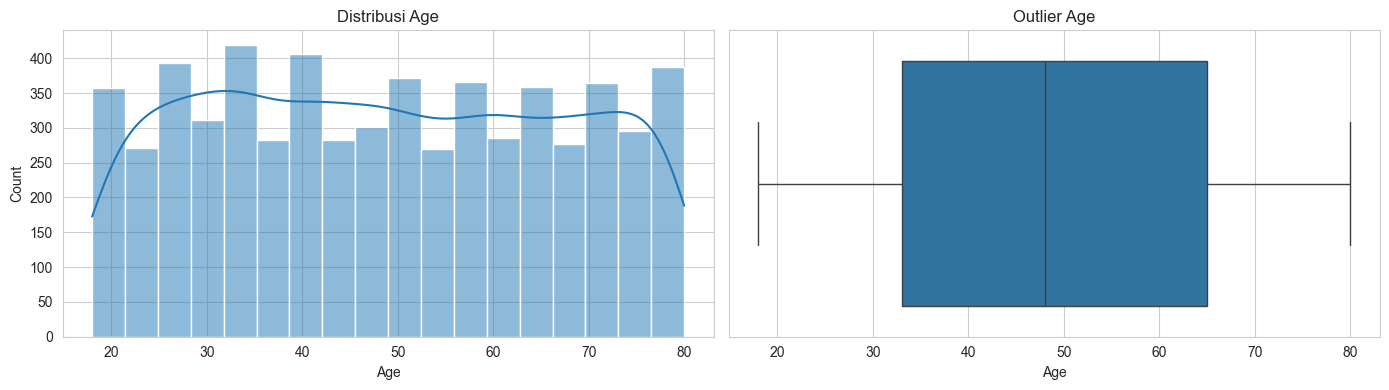

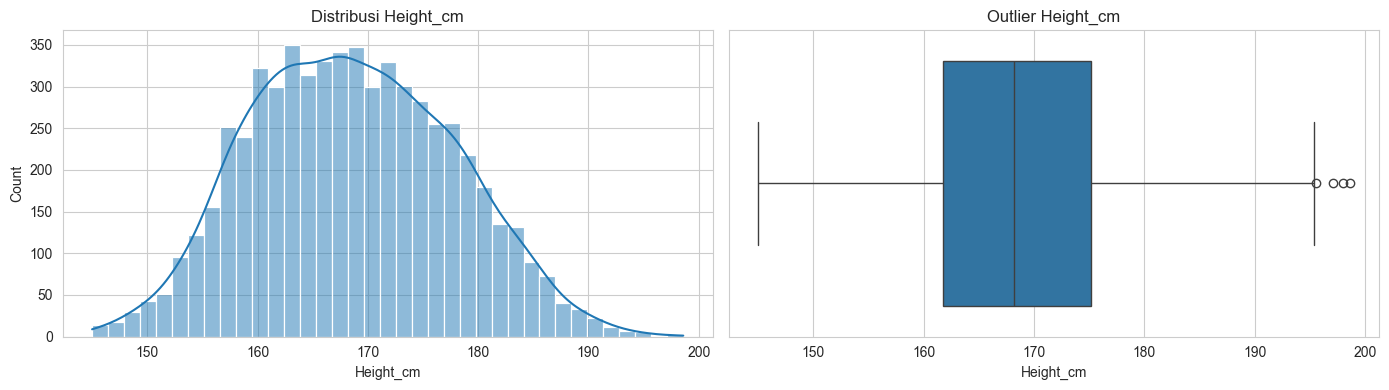

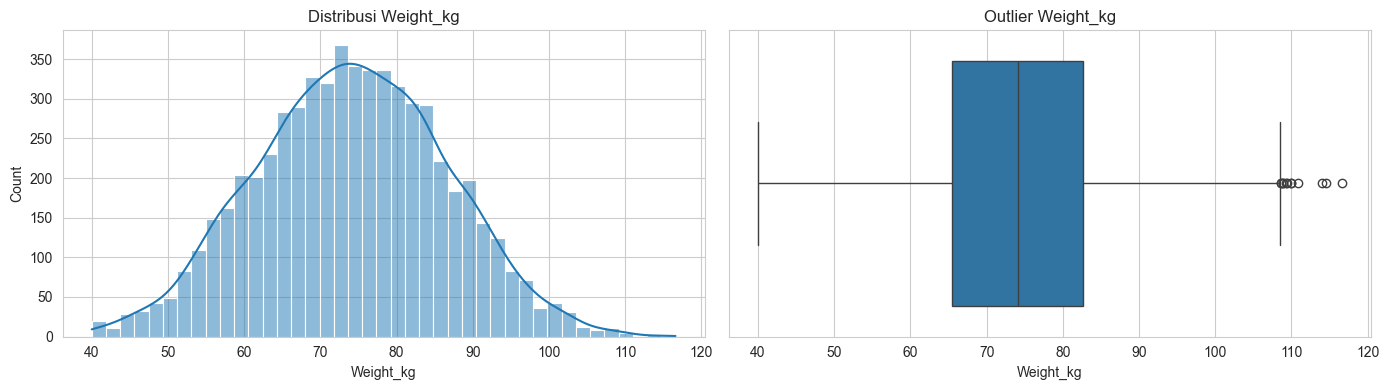

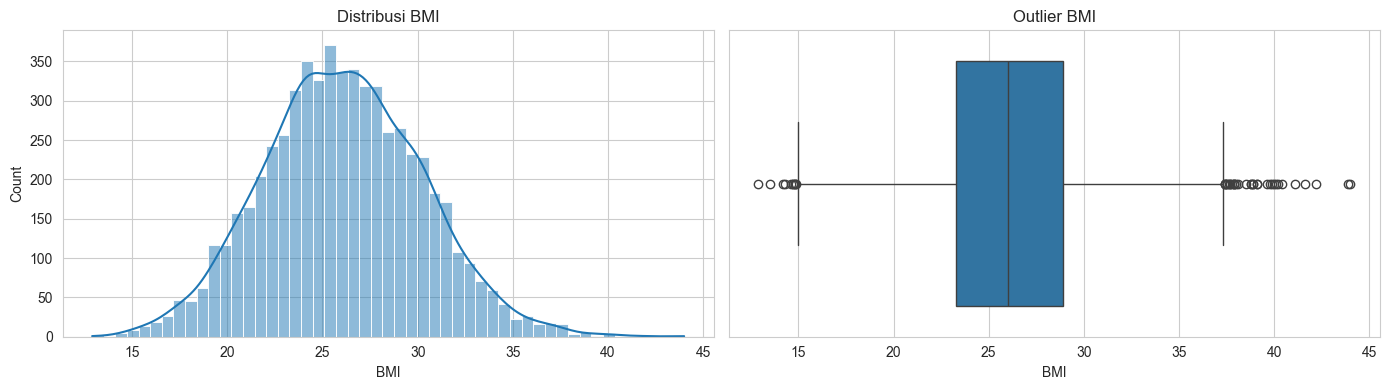

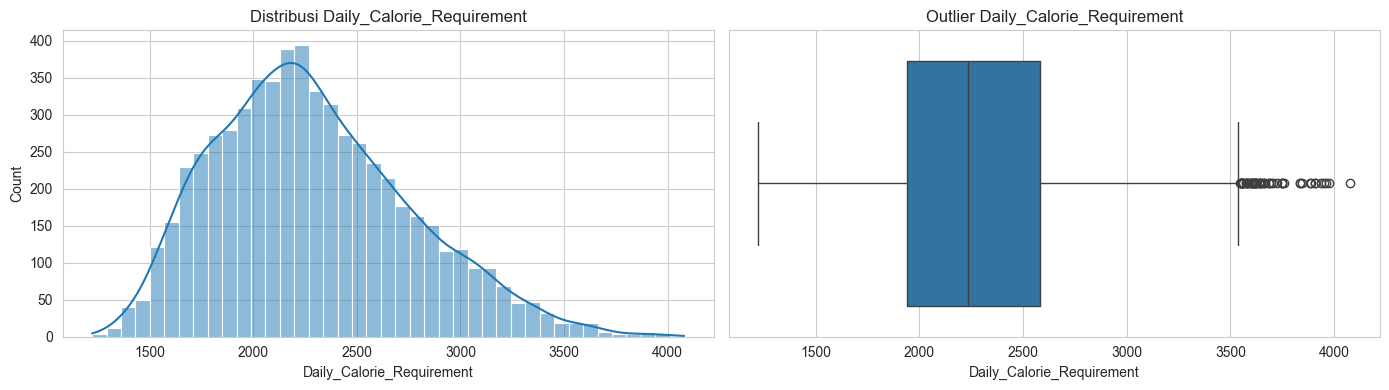

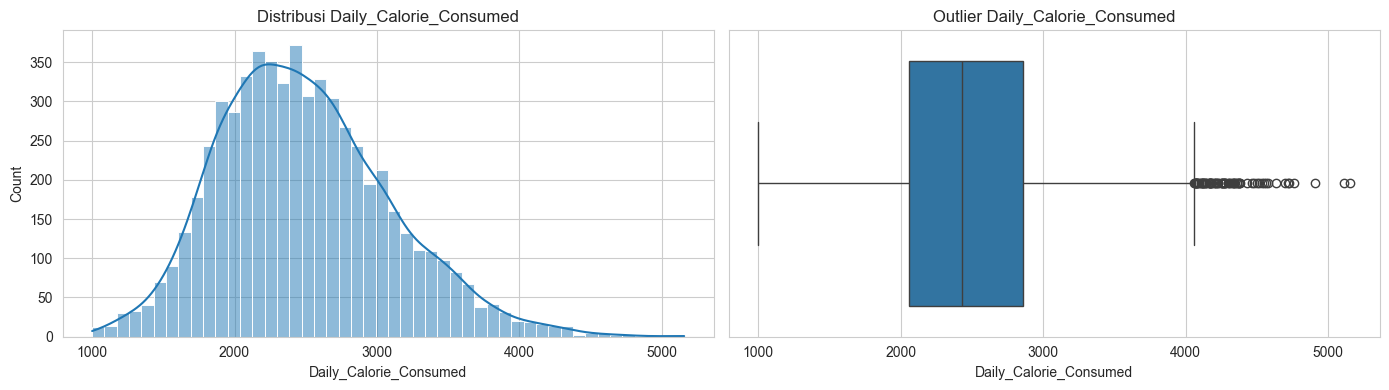

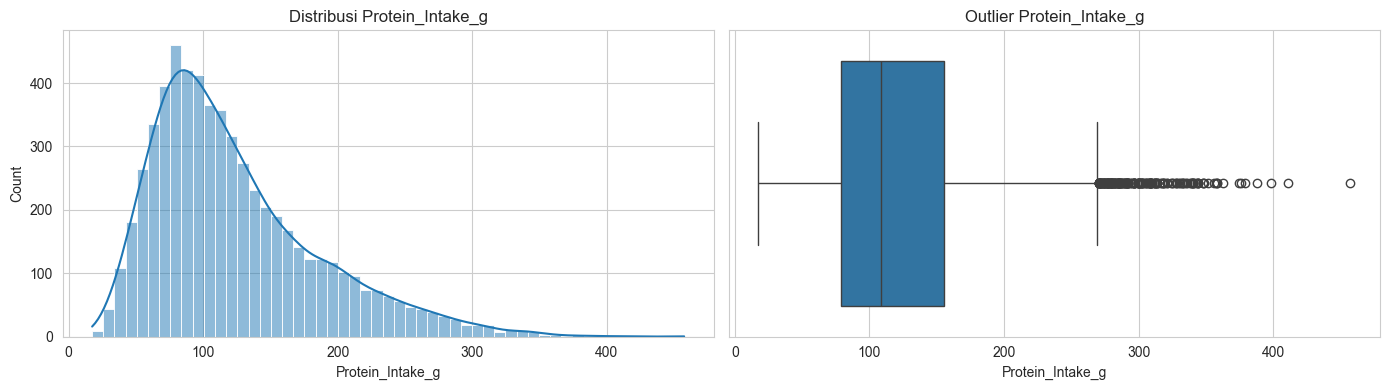

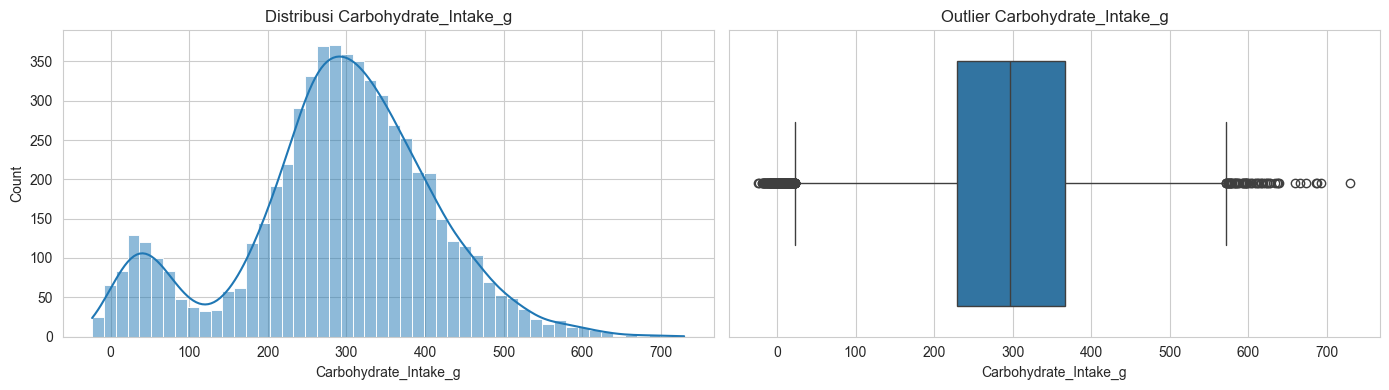

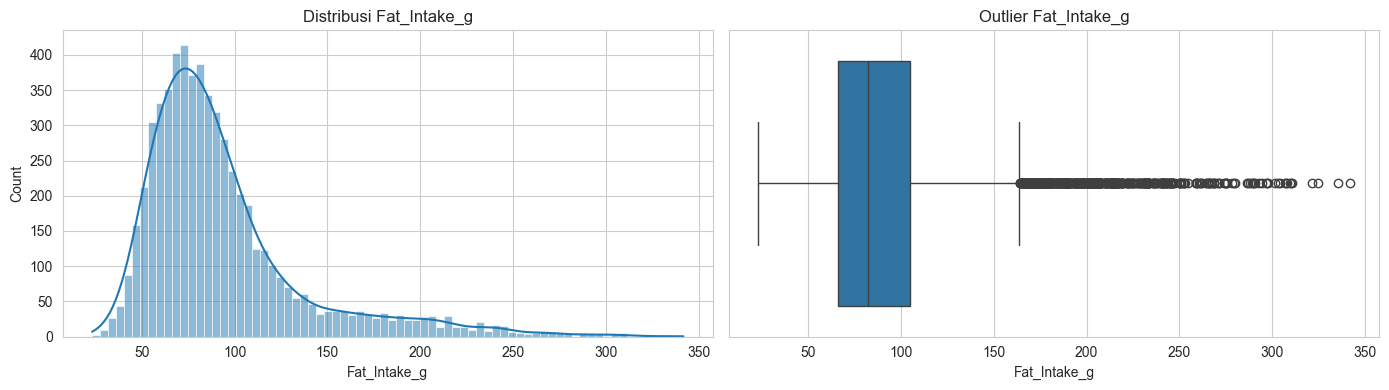

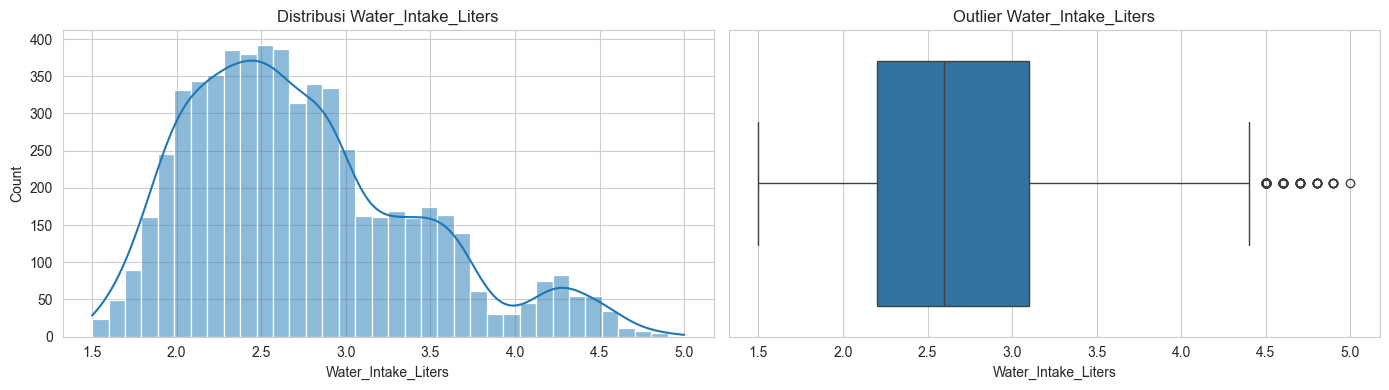

In [32]:
numeric_features = [col for col in num_cols if col != 'Person_ID']

for col in numeric_features:
    fig, ax = plt.subplots(1, 2, figsize=(14, 4))
    sns.histplot(df[col], kde=True, ax=ax[0])
    ax[0].set_title(f'Distribusi {col}')
    sns.boxplot(x=df[col], ax=ax[1])
    ax[1].set_title(f'Outlier {col}')
    plt.tight_layout()
    plt.show()

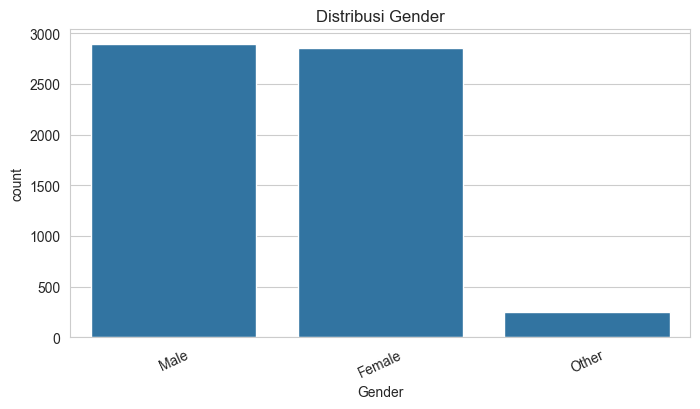

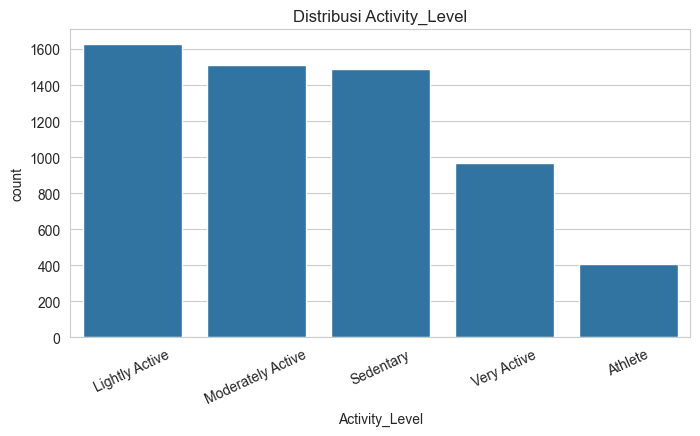

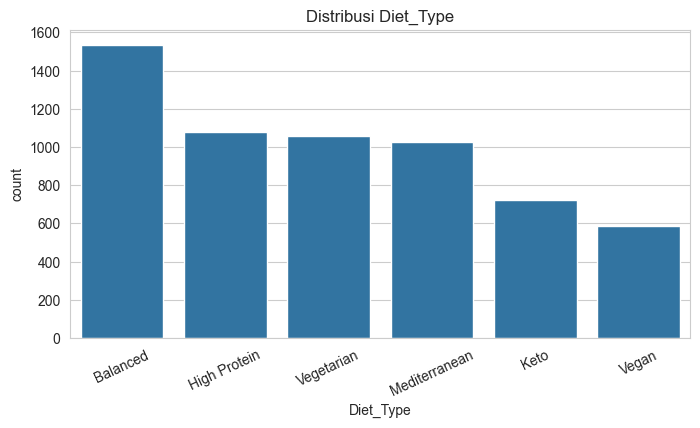

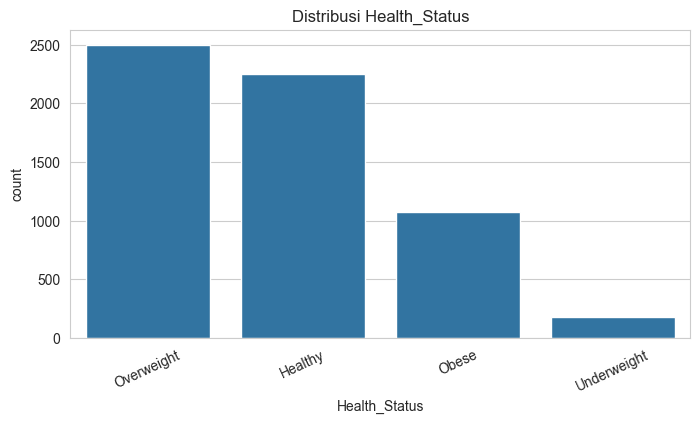

In [33]:
categorical_features = [col for col in cat_cols if col != 'Person_ID']

for col in categorical_features:
    plt.figure(figsize=(8,4))
    order = df[col].value_counts().index
    sns.countplot(data=df, x=col, order=order)
    plt.title(f'Distribusi {col}')
    plt.xticks(rotation=25)
    plt.show()

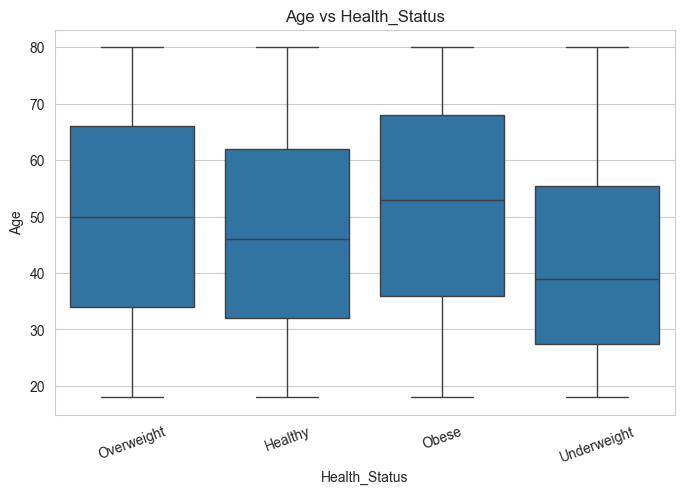

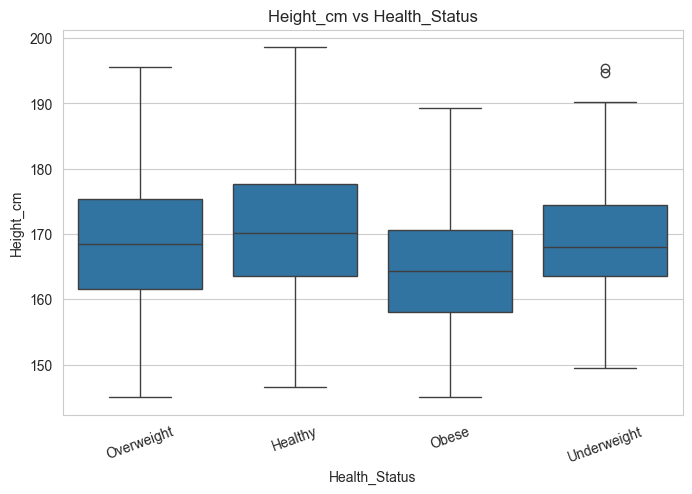

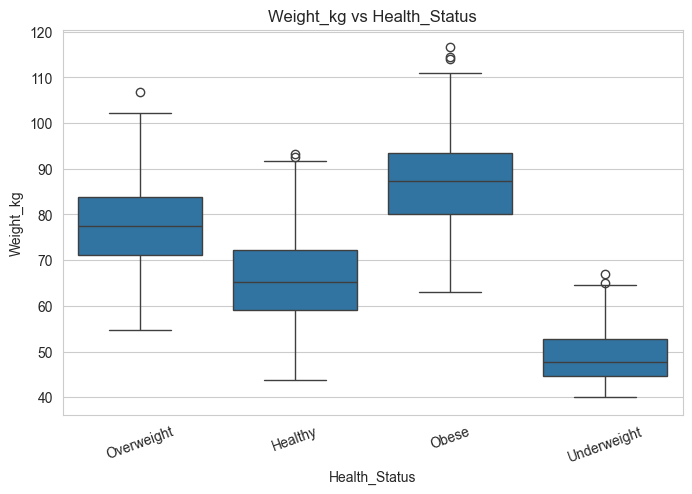

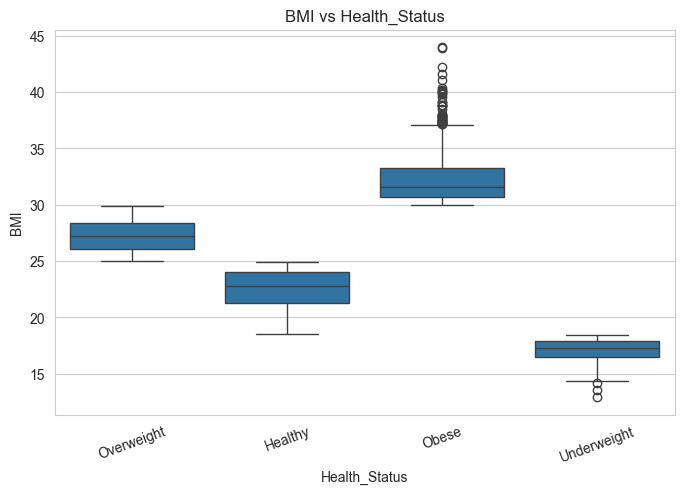

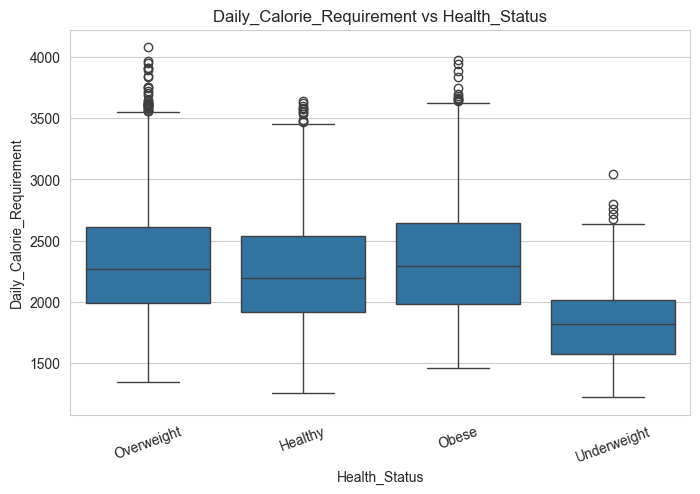

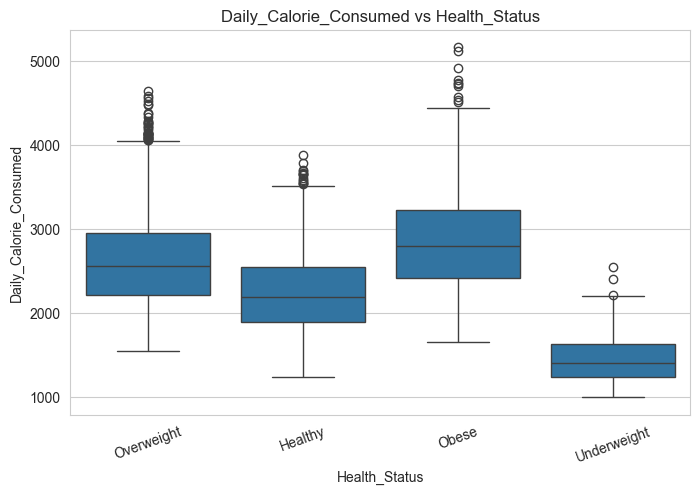

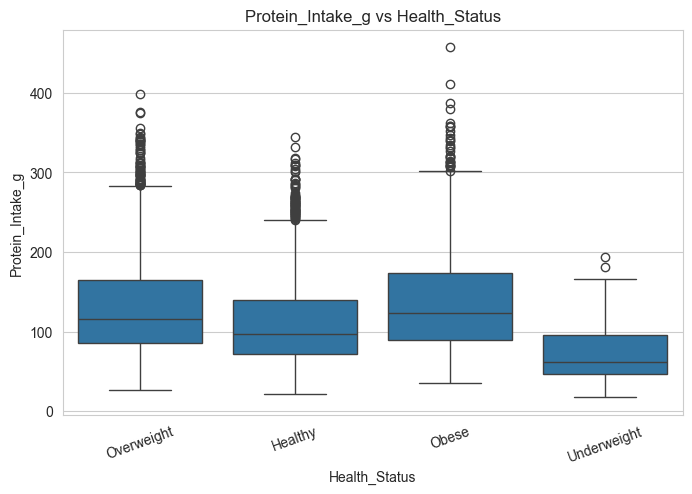

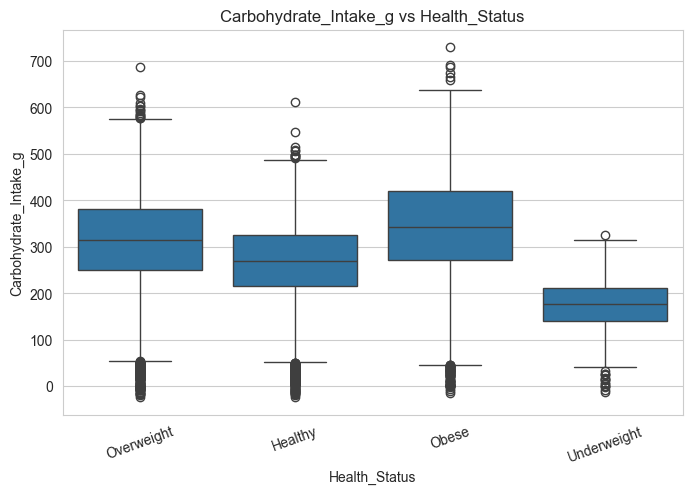

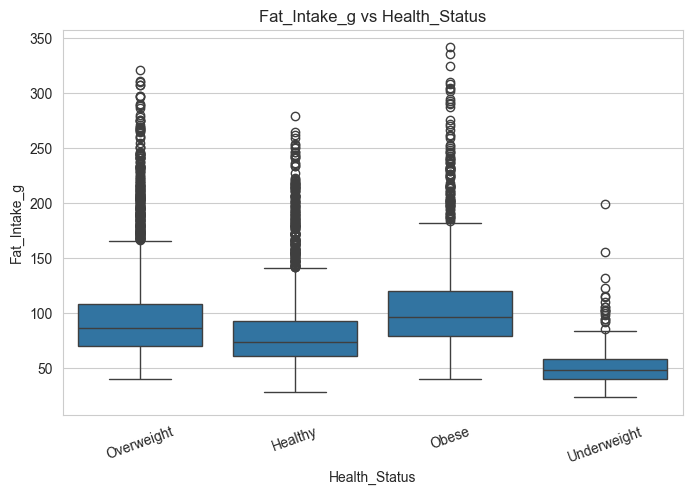

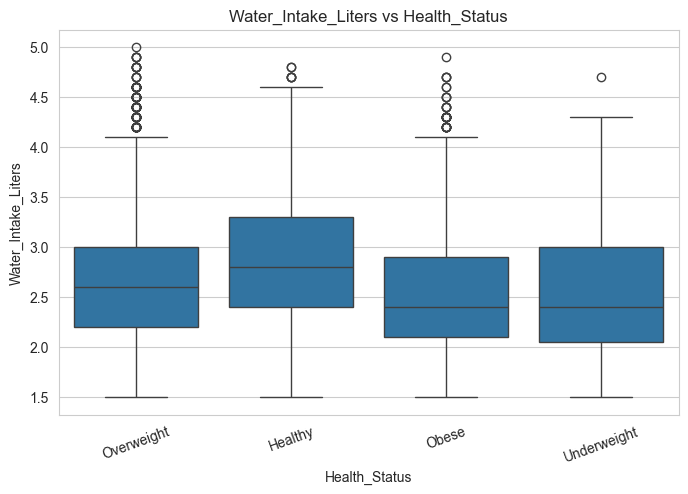

In [34]:
for col in numeric_features:
    if col == 'Person_ID':
        continue
    plt.figure(figsize=(8,5))
    sns.boxplot(data=df, x='Health_Status', y=col, order=df['Health_Status'].value_counts().index)
    plt.title(f'{col} vs Health_Status')
    plt.xticks(rotation=20)
    plt.show()

In [35]:
grouped = df.groupby('Health_Status')[numeric_features].mean(numeric_only=True)
grouped.round(2)

,Age,Height_cm,Weight_kg,BMI,Daily_Calorie_Requirement,Daily_Calorie_Consumed,Protein_Intake_g,Carbohydrate_Intake_g,Fat_Intake_g,Water_Intake_Liters
Health_Status,,,,,,,,,,
Healthy,46.89,170.73,65.83,22.52,2249.10,2244.66,111.55,260.61,84.00,2.86
Obese,51.56,164.33,87.20,32.26,2334.29,2865.74,139.42,332.24,108.79,2.54
Overweight,49.80,168.45,77.60,27.29,2330.58,2622.56,131.59,302.05,98.67,2.72
Underweight,42.61,169.35,48.95,17.03,1834.03,1456.74,72.97,168.49,54.55,2.56


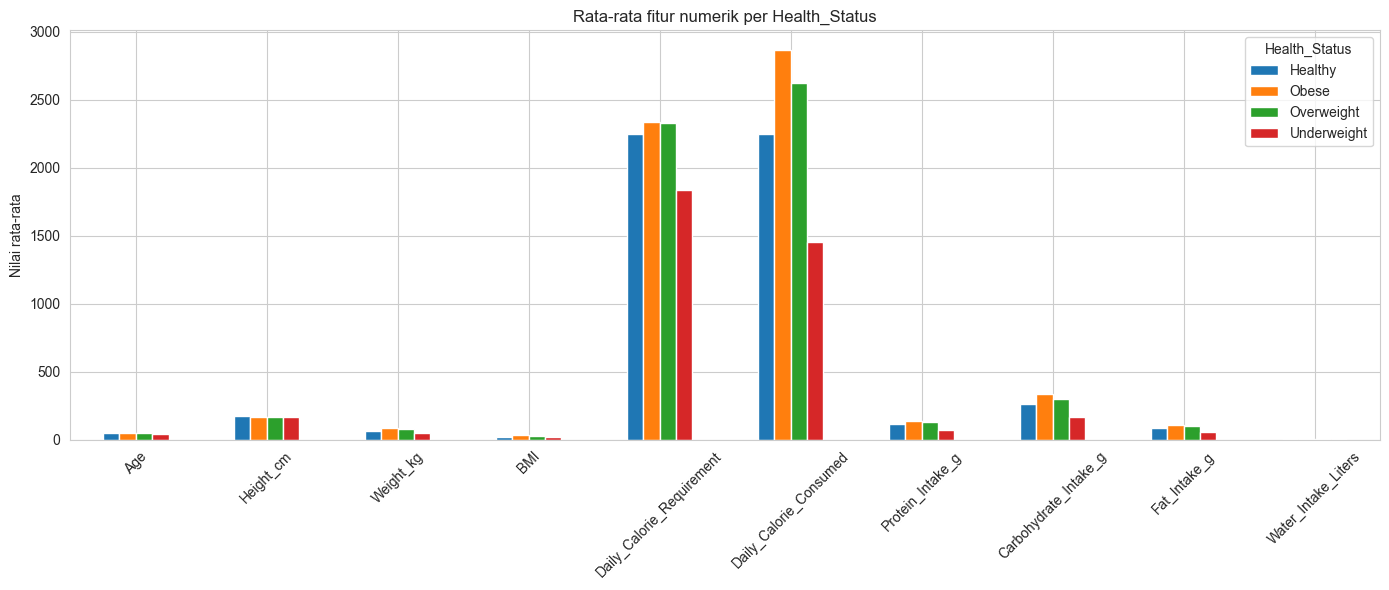

In [36]:
grouped.T.plot(kind='bar', figsize=(14,6))
plt.title('Rata-rata fitur numerik per Health_Status')
plt.ylabel('Nilai rata-rata')
plt.xticks(rotation=45)
plt.legend(title='Health_Status')
plt.tight_layout()
plt.show()

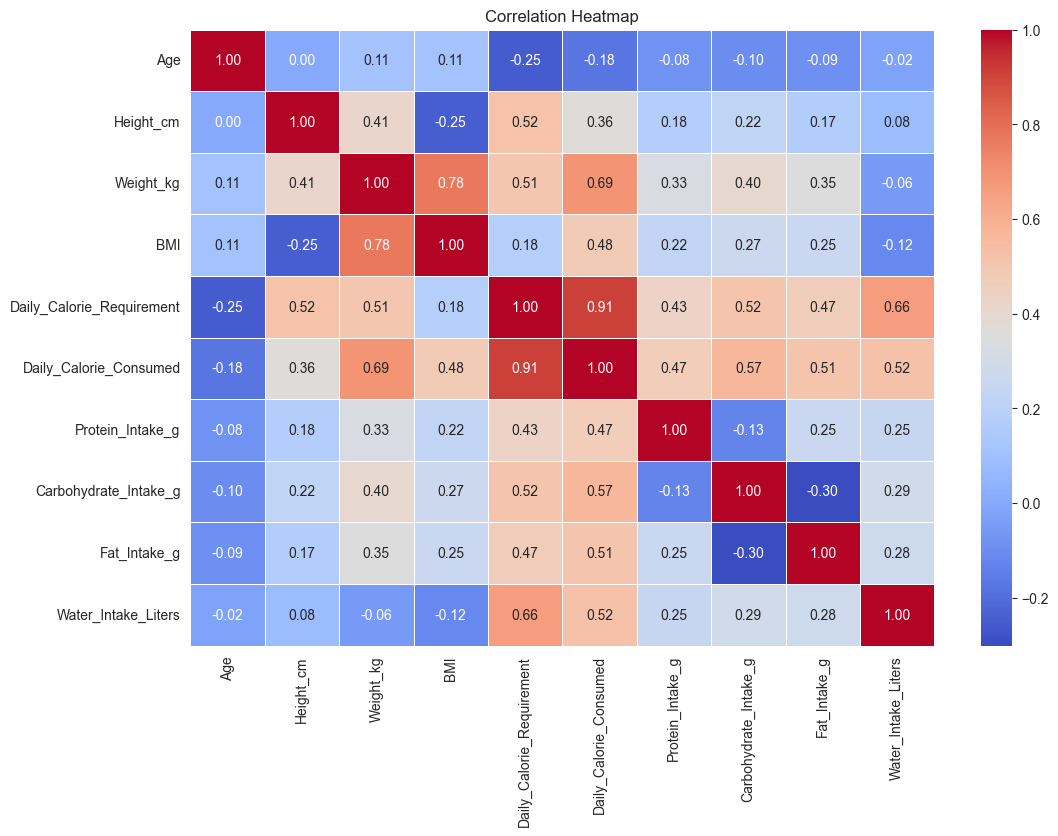

In [37]:
plt.figure(figsize=(12,8))
corr = df[numeric_features].corr()
sns.heatmap(corr, annot=True, cmap='coolwarm', fmt='.2f', linewidths=0.5)
plt.title('Correlation Heatmap')
plt.show()

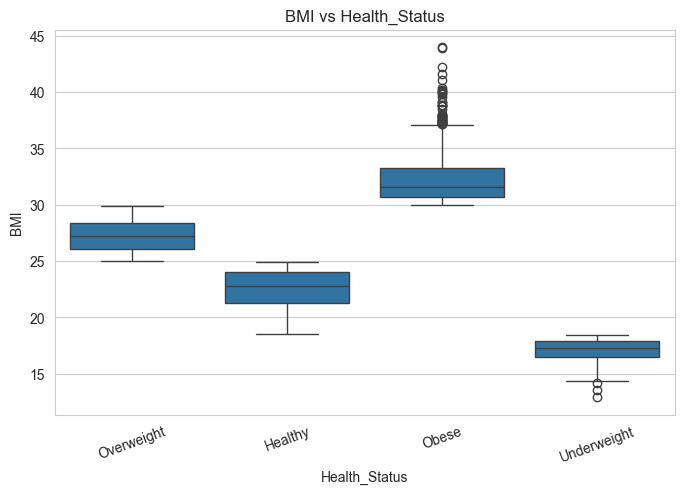

In [38]:
plt.figure(figsize=(8,5))
sns.boxplot(data=df, x='Health_Status', y='BMI', order=df['Health_Status'].value_counts().index)
plt.title('BMI vs Health_Status')
plt.xticks(rotation=20)
plt.show()

In [39]:
df.groupby('Health_Status')['BMI'].agg(['min', 'median', 'mean', 'max']).round(2)

,min,median,mean,max
Health_Status,,,,
Healthy,18.5,22.8,22.52,24.9
Obese,30.0,31.6,32.26,44.0
Overweight,25.0,27.2,27.29,29.9
Underweight,12.9,17.3,17.03,18.4


Seperate the Features and Target values

In [43]:
# Person_ID tidak dipakai sebagai fitur karena hanya identifier
X = df.drop(columns=['Health_Status', 'Person_ID', 'Daily_Calorie_Requirement', 'Daily_Calorie_Consumed', 'Protein_Intake_g', 'Carbohydrate_Intake_g', 'Fat_Intake_g', 'Water_Intake_Liters', 'Diet_Type' ])
y = df['Health_Status']

In [44]:
num_features = X.select_dtypes(include=np.number).columns.tolist()
cat_features = X.select_dtypes(exclude=np.number).columns.tolist()

numeric_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

categorical_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('onehot', OneHotEncoder(handle_unknown='ignore'))
])

preprocessor = ColumnTransformer(transformers=[
    ('num', numeric_transformer, num_features),
    ('cat', categorical_transformer, cat_features)
])

In [45]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print(X_train.shape, X_test.shape)

(4800, 6) (1200, 6)


Train the models

In [46]:
models = {
    'Logistic Regression': LogisticRegression(max_iter=100, class_weight='balanced'),
    'Decision Tree': DecisionTreeClassifier(random_state=42, class_weight='balanced'),
    'Random Forest': RandomForestClassifier(
        n_estimators=300,
        random_state=42,
        class_weight='balanced_subsample'
    ),
    'Gradient Boosting': GradientBoostingClassifier(random_state=42)
}

results = []
trained_pipelines = {}

for name, model in models.items():
    pipe = Pipeline(steps=[
        ('preprocessor', preprocessor),
        ('model', model)
    ])
    pipe.fit(X_train, y_train)
    y_pred = pipe.predict(X_test)
    acc = accuracy_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred, average='macro')
    results.append({'Model': name, 'Accuracy': acc, 'F1 Macro': f1})
    trained_pipelines[name] = pipe

results_df = pd.DataFrame(results).sort_values(by='F1 Macro', ascending=False)
results_df

,Model,Accuracy,F1 Macro
1,Decision Tree,1.000,1.000000
2,Random Forest,1.000,1.000000
3,Gradient Boosting,1.000,1.000000
0,Logistic Regression,0.975,0.956412


In [47]:
best_model_name = results_df.iloc[0]['Model']
best_model = trained_pipelines[best_model_name]

print('Best model:', best_model_name)
y_pred = best_model.predict(X_test)

print('Accuracy:', accuracy_score(y_test, y_pred))
print('\nClassification Report:\n')
print(classification_report(y_test, y_pred))

Best model: Decision Tree
Accuracy: 1.0

Classification Report:

              precision    recall  f1-score   support

     Healthy       1.00      1.00      1.00       450
       Obese       1.00      1.00      1.00       215
  Overweight       1.00      1.00      1.00       500
 Underweight       1.00      1.00      1.00        35

    accuracy                           1.00      1200
   macro avg       1.00      1.00      1.00      1200
weighted avg       1.00      1.00      1.00      1200



Best Model Evaluation 

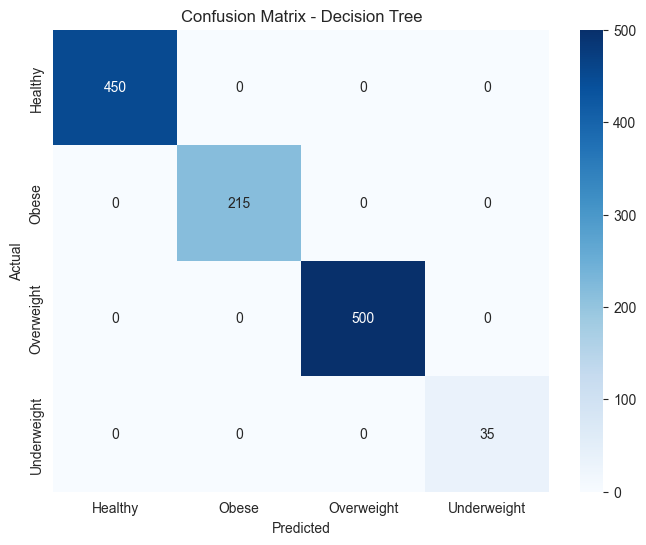

In [48]:
cm = confusion_matrix(y_test, y_pred, labels=best_model.classes_)
plt.figure(figsize=(8,6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=best_model.classes_,
            yticklabels=best_model.classes_)
plt.title(f'Confusion Matrix - {best_model_name}')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

Testing the model

In [49]:
sample = pd.DataFrame([{
    'Age': 30,
    'Gender': 'Male',
    'Height_cm': 172.0,
    'Weight_kg': 68.0,
    'BMI': 23.0,
    'Activity_Level': 'Moderately Active',
    'Daily_Calorie_Requirement': 2400,
    'Daily_Calorie_Consumed': 2300,
    'Protein_Intake_g': 120.0,
    'Carbohydrate_Intake_g': 260.0,
    'Fat_Intake_g': 70.0,
    'Water_Intake_Liters': 2.5,
    'Diet_Type': 'Balanced'
}])

predicted_class = best_model.predict(sample)[0]
print('Predicted Health Status:', predicted_class)

Predicted Health Status: Healthy


Saved Model

In [50]:
joblib.dump(best_model, 'Model/health_status_model.pkl')
print('Model saved as health_status_model.pkl')

Model saved as health_status_model.pkl
